# Analysis of single experiment

## 1. Define path

In [ ]:
# # GREEN
# dPaths = ["/media/DATA/MAK/GRISZ_02/AA0001",
#           "/media/DATA/MAK/GRISZ_03/AA0001",
#           "/media/DATA/MAK/GRISZ_05/AA0001",
# ]
# EXAMPLE DATA (format = 'PAC')
# dPaths = ["../data/AA0308","../data/AA0315"]
dPaths = ["/media/DATA/MAK/TL_B10_Mouse04/AA0001"]

## 2. Initialize experiment object

In [ ]:
import lib.experiment_oop as exp
import importlib
importlib.reload(exp)

# define baseline and response windows
t_base = (2.0, 3.0)
t_resp = (3.3, 4.0)

# subfolder (bool): Whether to search recursively within subfolders for qcam files.
e0 = exp.Experiment(dPaths[0], subfolder=True, t_base = t_base, t_resp = t_resp)
e0

,qcam,dir,xsg,pulse,dB,treatment
6,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,preZX1
7,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0,preZX1
8,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,6-64kHz_55dB_10000msTotal_Fs250kHz,55.0,preZX1
9,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,preZX1
10,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,6-64kHz_35dB_10000msTotal_Fs250kHz,35.0,preZX1
...,...,...,...,...,...,...
133,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AA...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,preZX1
134,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AZ...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AZ...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,postZX1
135,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AZ...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AZ...,6-64kHz_55dB_10000msTotal_Fs250kHz,55.0,postZX1
136,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AZ...,/media/DATA/MAK/TL_B10_Mouse04/AA0001,/media/DATA/MAK/TL_B10_Mouse04/AA0001/AA0001AZ...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,postZX1


In [3]:
# view trace count by treatment
e0.df['treatment'].value_counts()

treatment
preZX1     73
postZX1    58
Name: count, dtype: int64

## 3. Load qcam data

In [ ]:
#         exclude_non_loop_trials (bool, optional): Whether to remove trials collected outside of collection loop.
#         loop_gap_s (float, optional): Time gap (in seconds) between adjacent trials within the collection loop.
#                                    If `exclude_non_loop_trials` is `True`, first few trials with gaps above this threshold will be removed.

e0.load_qcam_data(exclude_non_loop_trials = True, loop_gap_s = 30)
e0

## 4. Overview plots (without ROI)

In [16]:
# rough first view of average across all traces
e0.plot_average_fluorescence()

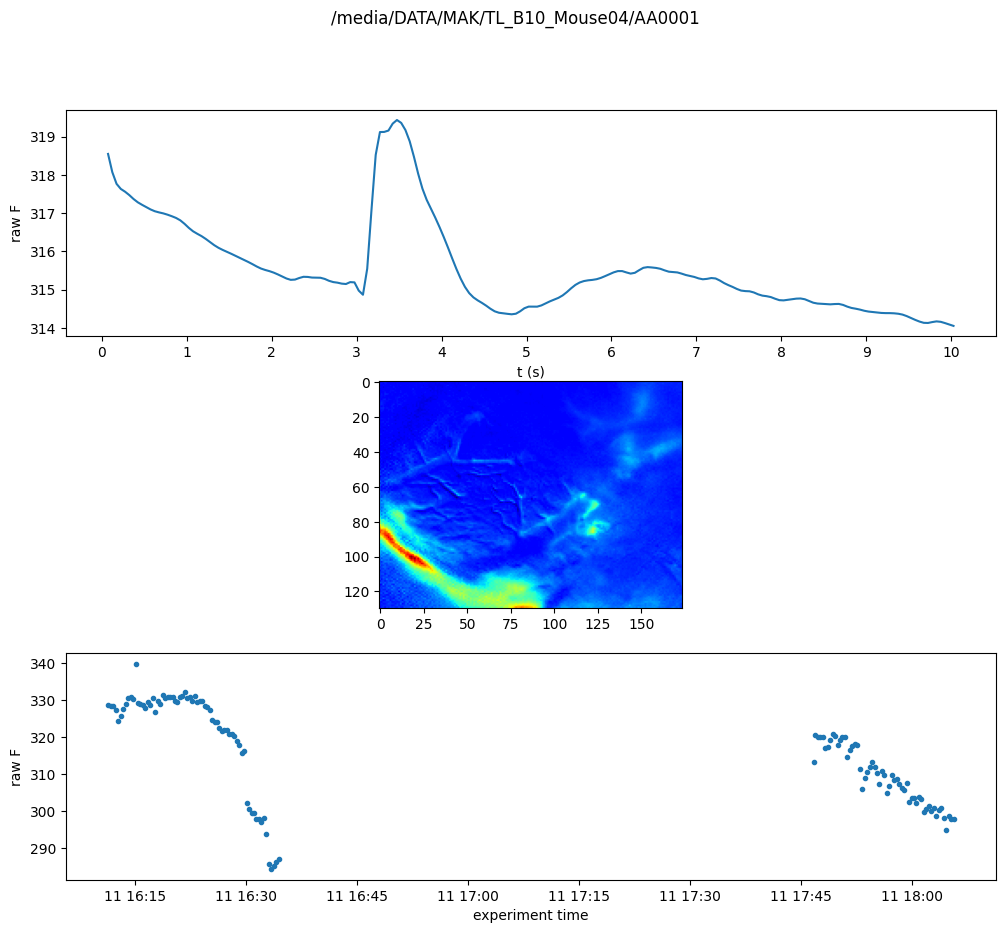

In [17]:
e0.plot_experiment_overview()

In [18]:
# without ROI selection
e0.plotDF_levelByTreatment()

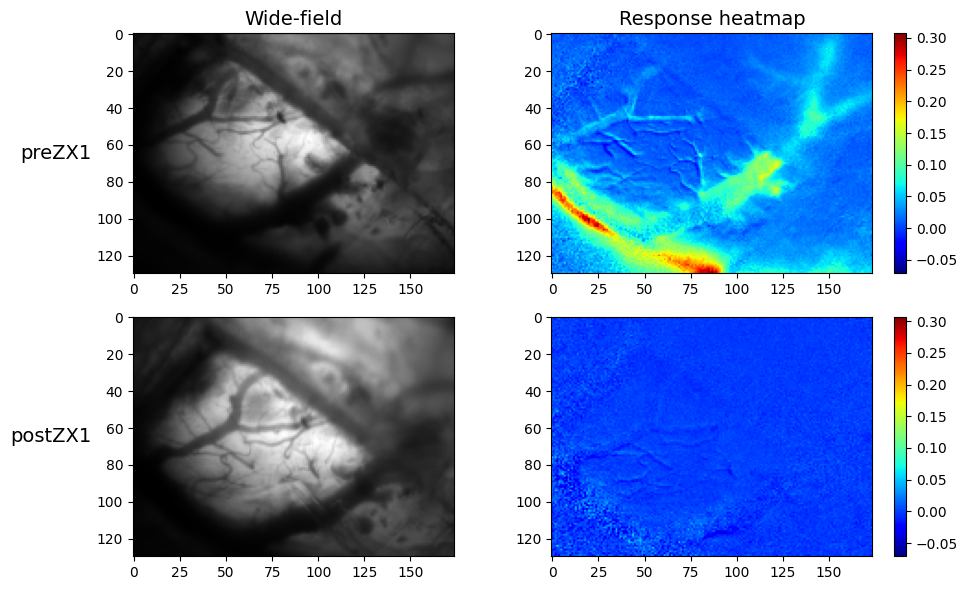

In [19]:
# view spatial dFF re condition
# specify sound intensity, baseline and response time window
dB_plot = 80

e0.plot_respHeatmap(dB_plot=dB_plot)

## 5. Draw ROI and save to experiment directory (via button)

In [ ]:
# SAME ROI regardless of treatment
# ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask()

# Separate ROI by treatment
ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask(condition='pre')
# ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask(condition='post')

# Load existing ROI
# import lib.imgProcess as imgProcess
# defined_mask = imgProcess.getSquareMask(5, 85, 40, 10, angle=90, rotate=30)
# ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask(condition='post', existing_roi = defined_mask['ROIcontour'])

In [7]:
ui

BokehModel(combine_events=True, render_bundle={'docs_json': {'826c0944-2a62-4a60-9714-2da9ee9506c1': {'version…

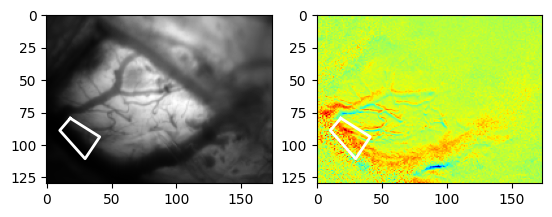

In [8]:
e0.plot_ROI_mask(mask_output, imgSeries, spatialDFF)

## 6. Process qcam files re saved ROI and apply criteria + filtering

In [ ]:
e0.process_signal()
e0

/home/pac/Documents/Python/pyFluo/src/lib/signalProcess.py:569: UserWarning:

Multiple pre masks found in /media/DATA/MAK/TL_B10_Mouse04/AA0001: ['/media/DATA/MAK/TL_B10_Mouse04/AA0001/response_mask_pre.joblib', '/media/DATA/MAK/TL_B10_Mouse04/AA0001/response_mask_pre_001.joblib', '/media/DATA/MAK/TL_B10_Mouse04/AA0001/response_mask_pre_002.joblib'], using /media/DATA/MAK/TL_B10_Mouse04/AA0001/response_mask_pre.joblib



## 7. Plot processed data re ROI

In [ ]:
# TODO: plotDF_levelByTreatment with df + response col instead of qcam2img (can add logic to existing function)
# e0.plotDF_levelByTreatment(roi_mask=mask_output['mask'])

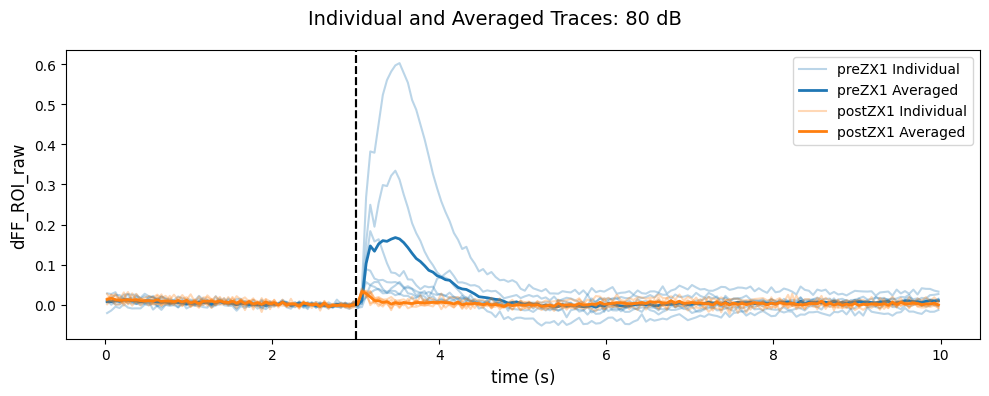

In [ ]:
# TODO: add this to experiment_oop.py
import lib.plotting as plotting
plotting.plot_traces(e0.df, dB_plot=80, resp_col='dFF_ROI_raw', sepPlot=False)

In [ ]:
# TODO: add this to experiment_oop.py
import plotly.express as px

fig = px.violin(e0.df, y="dFF_ROI_linFilt_butterFilt_peak", x="dB", color="treatment", box=True, points='all')
fig.show()
